To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [8]:
%%capture
import os
os.kill(os.getpid(), 9)
import re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth

# Lệnh cài thẳng Unsloth và Transformers mới nhất từ Github (có hỗ trợ Gemma 4)
!pip install --upgrade git+https://github.com/huggingface/transformers.git
!pip install --upgrade git+https://github.com/unslothai/unsloth.git
!pip install --no-deps trl==0.22.2
!unrar x gemma4_web_dataset.rar gemma4_web_dataset/

In [ ]:
!pip uninstall -y transformers
!pip install git+https://github.com/huggingface/transformers.git

# Dòng này ép Colab tự động Restart lại môi trường ngay lập tức
import os
os.kill(os.getpid(), 9)


Found existing installation: transformers 5.6.0.dev0
Uninstalling transformers-5.6.0.dev0:
  Successfully uninstalled transformers-5.6.0.dev0
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-9vu_v2j1
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-9vu_v2j1
  Resolved https://github.com/huggingface/transformers.git to commit b9f0fbf532c124ff836466d896a716e26dbe4722
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11359424 sha256=6423a71ded3423b36b473e4002f6a53a9fb7f6832897f911eb618a44fc566170
  Stored in directory: /tmp/pip-ephem-wheel-cache-lu1vxni2/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
ERROR: pip's dependency resolver does not currently take into acc

In [ ]:
import transformers
print(transformers.__version__)


### Unsloth

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-4-E4B-it-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

We now add LoRA adapters for parameter efficient fine-tuning, allowing us to train only 1% of all model parameters efficiently.

**[NEW]** We also support fine-tuning only the vision component, only the language component, or both. Additionally, you can choose to fine-tune the attention modules, the MLP layers, or both!

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    # CHỈ ĐỊNH ĐÍCH DANH CÁC LỚP NGÔN NGỮ (XÓA CHỮ "all-linear" đi)
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)


Unsloth: Making `model.base_model.model.model.language_model` require gradients


<a name="Data"></a>
### Data Prep
We'll use a sampled dataset of handwritten math formulas. The objective is to convert these images into a computer-readable format—specifically LaTeX—so they can be rendered. This is particularly useful for complex expressions.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Let's take an overview of the dataset. We'll examine the second image and its corresponding caption.

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

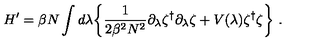

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

We can also render LaTeX directly in the browser!

In [ ]:
from IPython.display import display, Math, Latex

latex = dataset[3]["text"]
display(Math(latex))

<IPython.core.display.Math object>

To format the dataset, all vision fine-tuning tasks should follow this format:

```python
[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
]
```

In [ ]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": sample["text"]}]},
    ]
    return {"messages": conversation}
pass

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

The first example is now structured like below:

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

Lets take the Gemma 3 instruction chat template and use it in our base model

In [ ]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-3"
)

Before fine-tuning, let us evaluate the base model's performance. We do not expect strong results, as it has not encountered this chat template before.

In [ ]:
FastVisionModel.for_inference(model)  # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

You have set `compile_config`, but we are unable to meet the criteria for compilation. Compilation will be skipped.

model
model






<start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image><start_of_image>]](]
)]
]
]]
Write the LaTeX representation for this image.
.
.
.
Write the LaTeX representation for this image.
Write the LaTeX representation for this image.
Write the LaTeX representation for this image.
Write the LaTeX representation for this image.
Write the LaTeX representation for this image.
Write the LaTeX representation for this image.

You can see it's absolutely terrible! It doesn't follow instructions at all

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [4]:
import codecs

# 1. Đọc cái file đang bị lỗi dở dở ương ương kia (Dùng bảng mã Latin-1 để vớt lại Tiếng Việt)
with codecs.open('./gemma4_web_dataset/train_unsloth.jsonl', 'r', encoding='latin-1') as f_in:
    noidung_file = f_in.readlines()

# 2. Xả lại nó ra một cái file mới toanh chuẩn đét UTF-8
with codecs.open('./gemma4_web_dataset/train_unsloth_utf8.jsonl', 'w', encoding='utf-8') as f_out:
    f_out.writelines(noidung_file)

print("Đã vá lỗi xong! Hãy xài file train_unsloth_utf8.jsonl nhé!")


Đã vá lỗi xong! Hãy xài file train_unsloth_utf8.jsonl nhé!


In [5]:
from datasets import load_dataset
from PIL import Image

# 1. Đọc data từ file chuẩn UTF-8 nãy làm
dataset = load_dataset("json", data_files="./gemma4_web_dataset/train_unsloth_utf8.jsonl", split="train")

# 2. Hàm đọc ảnh và nhúng ảnh
def cast_image_path_to_image(sample):
    for i, message in enumerate(sample['messages']):
        for j, content in enumerate(message['content']):
             if content['type'] == 'image':
                 # Nối đường dẫn
                 img_path = "./gemma4_web_dataset/" + content['image']

                 # DÙNG THƯ VIỆN ĐỂ MỞ ẢNH THỰC TẾ LÊN
                 anh_thuc_te = Image.open(img_path).convert("RGB")

                 # Thay thế text đường dẫn bằng Bức ảnh đó
                 sample['messages'][i]['content'][j] = {
                     "type": "image",
                     "image": anh_thuc_te
                 }
    return sample

# 3. Tạo List dữ liệu mượt mà, y chang bản gốc của họ
converted_dataset = [cast_image_path_to_image(mau_data) for mau_data in dataset]

print("Thành công! Mọi ảnh đã được nạp vào dataset. Chuẩn bị qua bước Train đê!")


Generating train split: 0 examples [00:00, ? examples/s]

Thành công! Mọi ảnh đã được nạp vào dataset. Chuẩn bị qua bước Train đê!


In [6]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    train_dataset = converted_dataset,
    processing_class = processor.tokenizer,
    data_collator = UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        gradient_checkpointing = True,

        # use reentrant checkpointing
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        max_grad_norm = 0.3,              # max gradient norm based on QLoRA paper
        warmup_ratio = 0.03,
        #max_steps = 30,
        num_train_epochs = 2,          # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_torch_fused",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",             # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

Unsloth: Model does not have a default image size - using 512


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [14]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
10.227 GB of memory reserved.


In [7]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,460 | Num Epochs = 2 | Total steps = 730
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,222,144 of 8,037,378,592 (0.51% trained)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (2520x768 and 1x294912)

In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

760.6053 seconds used for training.
12.68 minutes used for training.
Peak reserved memory = 6.061 GB.
Peak reserved memory for training = 0.645 GB.
Peak reserved memory % of max memory = 41.117 %.
Peak reserved memory for training % of max memory = 4.376 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can modify the instruction and input—just leave the output blank.

We'll use the best hyperparameters for inference on Gemma: `top_p=0.95`, `top_k=64`, and `temperature=1.0`.

In [ ]:
FastVisionModel.for_inference(model)  # Enable for inference!

image = dataset[10]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]

input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

[
\left( { B _ { n } ^ { + } , { q } _ { 2 } , { k } _ { 2 } ^ { + } \right)
[
\left. { { q } _ { 2 } , k _ { 2 } ^ { + } { k } _ { 2 } ^ { + } , { q } _ { 2 } ^ { + } } \right]
= n B _ { n } ^ { + } , { q _ { 2 } }
image<end_of_turn>

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, use Hugging Face’s `push_to_hub` for online saving, or `save_pretrained` for local storage.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("gemma_3_lora")  # Local saving
processor.save_pretrained("gemma_3_lora")
# model.push_to_hub("your_name/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving
# processor.push_to_hub("your_name/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving

['lora_model/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel

    model, processor = FastVisionModel.from_pretrained(
        model_name = "gemma_3_lora",  # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True,  # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model)  # Enable for inference!

FastVisionModel.for_inference(model)  # Enable for inference!

sample = dataset[1]
image = sample["image"].convert("RGB")
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": sample["text"],
            },
            {
                "type": "image",
            },
        ],
    },
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor.tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

A _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,<end_of_turn>

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", processor,)


And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)
</div>